In [2]:
#TODO MARCIN
import os
import librosa
import kaggle
import numpy as np
from glob import glob
from pathlib import Path
import pandas as pd

from matplotlib import pyplot as plt

download recordings

In [3]:
#TODO MARCIN
if not os.path.exists("../preprocessing_pipeline/data"):
    kaggle.api.authenticate()
    kaggle.api.dataset_download_files('quochoangvuvan/ml-voice-recognition', path=".", unzip=True)
    print(kaggle.api.dataset_list_files('quochoangvuvan/ml-voice-recognition').files)
    kaggle.api.dataset_metadata('quochoangvuvan/ml-voice-recognition', path=".")

#class0_files = glob("./data/Class0/*/*.mp3")
#class1_files = glob("./data/Class1/*/*.mp3")

class0_dirs = [d for d in Path("../preprocessing_pipeline/data/Class0").iterdir()]
class0_speakers = {}
for speaker_dir in class0_dirs:
    speaker_name = speaker_dir.name
    audio_files = list(speaker_dir.glob('*.mp3'))
    class0_speakers[speaker_name] = audio_files

class1_dirs = [d for d in Path("../preprocessing_pipeline/data/Class1").iterdir()]
class1_speakers = {}
for speaker_dir in class1_dirs:
    speaker_name = speaker_dir.name
    audio_files = list(speaker_dir.glob('*.mp3'))
    class1_speakers[speaker_name] = audio_files


    #todo jak z noise

In [4]:
#TODO MARCIN
class0_count = len(class0_speakers)
class1_count = len(class1_speakers)

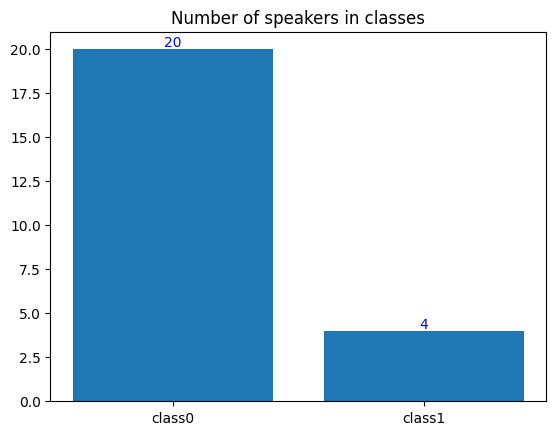

In [5]:
fig, ax = plt.subplots()
x_positions = [0, 1]
bars = ax.bar(['class0', 'class1'], [class0_count, class1_count])
#todo tutaj noise jako 1 speaker rozrozni
ax.bar_label(bars, label_type='edge', color='blue')
ax.title.set_text('Number of speakers in classes')
plt.show()

In [ ]:
#TODO get audio duration per speaker??

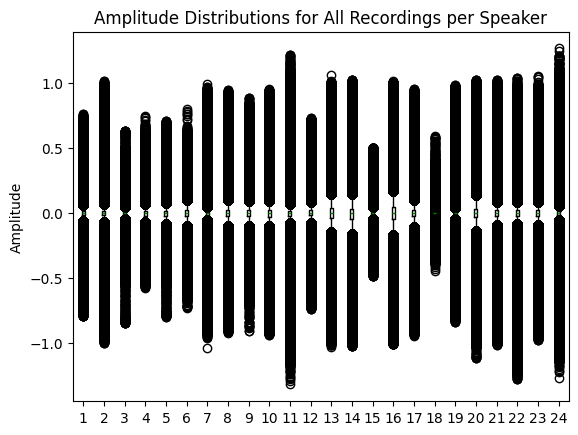

In [6]:
#TODO MARCIN - i honestly hate you Katarzyno
###
#no longer storing all the data >:C
#np arrays for better performance
###
import gc

fig, ax = plt.subplots()
current_position = 1

for speaker in class0_speakers:
    speaker_arr = np.concatenate([librosa.load(audio_file, sr=None)[0] for audio_file in class0_speakers[speaker]])
    ax.boxplot(speaker_arr, label=f"Class0_{speaker}", positions=[current_position], medianprops=dict(color='green'))
    del speaker_arr; gc.collect()
    current_position += 1


for speaker in class1_speakers:
    speaker_arr = np.concatenate([librosa.load(audio_file, sr=None)[0] for audio_file in class1_speakers[speaker]])
    ax.boxplot(speaker_arr, label=f"Class1_{speaker}", positions=[current_position], medianprops=dict(color='green'))
    del speaker_arr; gc.collect()
    current_position += 1

ax.set_title('Amplitude Distributions for All Recordings per Speaker')
ax.set_ylabel('Amplitude')
plt.show()

In [ ]:
#TODO MARCIN
# boxplots for all recordings from 1 speaker
# data = []
# labels = []
# for speaker, data in class0_speakers_data.items():
#     data.append(data)
#     labels.append(f"Class0_{speaker}")
#
# for speaker, data in class1_speakers_data.items():
#     data.append(data)
#     labels.append(f"Class1_{speaker}")
#
# fig, ax = plt.subplots()
# bp = ax.boxplot(data, tick_labels=labels,  medianprops=dict(color='green'))
#
# ax.set_title('Amplitude Distributions for All Recordings per Speaker')
# ax.set_ylabel('Amplitude')
# plt.show()


sampling rate of the original recordings

In [ ]:
#TODO what do i need the sampling rate for??

In [6]:
#TODO change to sum from all people
class0_sr = []
class1_sr = []

for speaker in class0_speakers:
    for f in class0_speakers[speaker]:
        # _, sr = librosa.load(f, sr=None)
        sr = librosa.get_samplerate(f)
        class0_sr.append(sr)

for speaker in class1_speakers:
    for f in class1_speakers[speaker]:
        # _, sr = librosa.load(f, sr=None)
        sr = librosa.get_samplerate(f)
        class1_sr.append(sr)

In [7]:
sr_stats = pd.DataFrame({
    "Class": ["Class 0", "Class 1"],
    "Count": [len(class0_sr), len(class1_sr)],
    "Mean": [np.mean(class0_sr), np.mean(class1_sr)],
    "Min": [np.min(class0_sr), np.min(class1_sr)],
    "Max": [np.max(class0_sr), np.max(class1_sr)]
})

sr_stats

,Class,Count,Mean,Min,Max
0,Class 0,81,42125.925926,16000,48000
1,Class 1,59,41564.406780,16000,48000


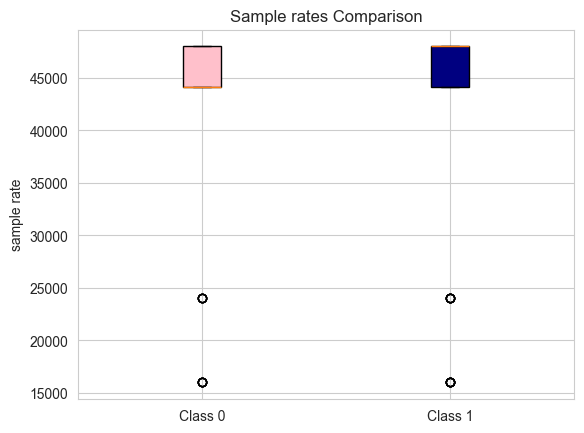

In [8]:
fig, axes = plt.subplots()
bp1 = axes.boxplot([class0_sr, class1_sr], tick_labels=['Class 0', 'Class 1'], patch_artist=True)
bp1['boxes'][0].set_facecolor('pink')
bp1['boxes'][1].set_facecolor('navy')
axes.set_ylabel('sample rate')
axes.set_title('Sample rates Comparison')
plt.show()

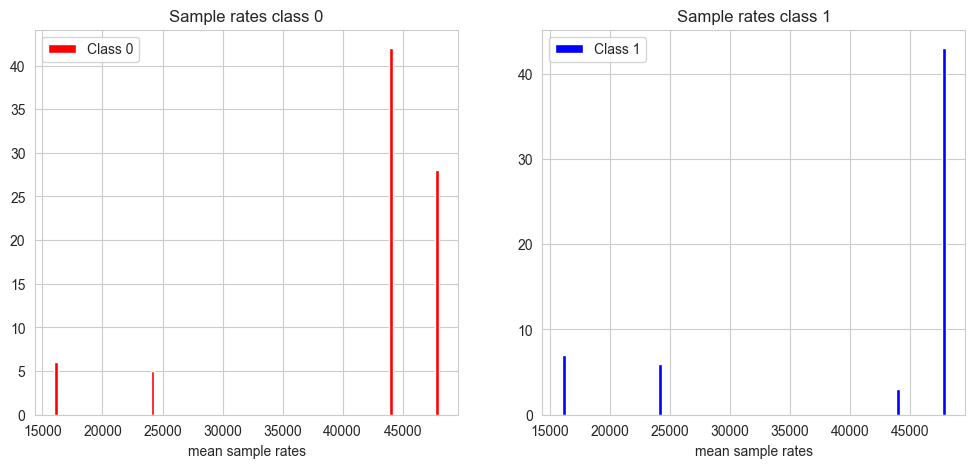

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].hist(class0_sr, bins=100, color='red', label='Class 0')
ax[1].hist(class1_sr, bins=100, color='blue', label='Class 1')

ax[0].set_title('Sample rates class 0')
ax[0].set_xlabel('mean sample rates')
ax[0].legend()

ax[1].set_title('Sample rates class 1')
ax[1].set_xlabel('mean sample rates')
ax[1].legend()

plt.show()

In [12]:
del class1_speakers, class0_speakers, class1_sr ,class0_sr
plt.close('all')   # closes all figures, frees the memory used by matplotlib
del fig, ax
gc.collect()

17901